| Blazar  | m_median [(M_sun)] | mdot_median |
| ------- | ---------------------------: | ---------------------: |
| J0021   |            (5.700\times10^9) |   (7.394\times10^{-3}) |
| J0050   |            (2.291\times10^8) |   (4.436\times10^{-3}) |
| J0059   |            (2.185\times10^8) |   (1.341\times10^{-2}) |
| J0133   |            (2.036\times10^9) |   (1.022\times10^{-2}) |
| J0508   |            (6.208\times10^5) |    (1.260\times10^{1}) |
| J0922   |         (3.643\times10^{10}) |   (9.795\times10^{-3}) |
| J1123   |            (4.540\times10^9) |   (6.853\times10^{-3}) |
| J1329   |         (2.984\times10^{10}) |   (9.633\times10^{-3}) |
| J1745   |            (2.657\times10^9) |   (7.629\times10^{-3}) |
| J1816   |         (3.037\times10^{10}) |   (9.922\times10^{-3}) |
| J2237   |            (1.767\times10^9) |   (7.084\times10^{-3}) |
| J152422 |         (4.751\times10^{10}) |   (1.137\times10^{-3}) |
| J170108 |            (1.302\times10^9) |   (5.701\times10^{-3}) |


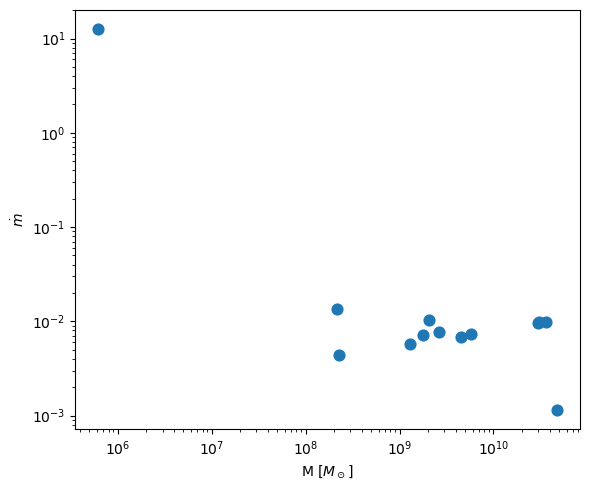

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("risultati_MCMC.csv")

plt.figure(figsize=(6,5))
plt.scatter(
    df["m_median_Msun"],
    df["mdot_median"],
    s=60)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"M [$M_\odot$]")
plt.ylabel(r"$\dot{m}$")
plt.tight_layout()
plt.show()

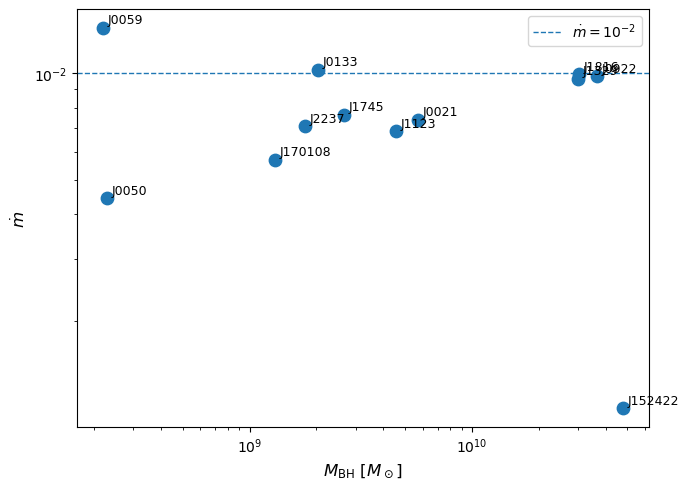

In [7]:
df_zoom = df[df["Blazar"] != "J0508"]

plt.figure(figsize=(7,5))

plt.scatter(
    df_zoom["m_median_Msun"],
    df_zoom["mdot_median"],
    s=80
)

for _, row in df_zoom.iterrows():
    plt.text(
        row["m_median_Msun"]*1.05,
        row["mdot_median"]*1.03,
        row["Blazar"],
        fontsize=9
    )

plt.axhline(1e-2, linestyle="--", linewidth=1, label=r"$\dot{m}=10^{-2}$")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$M_{\rm BH}$ [$M_\odot$]", fontsize=12)
plt.ylabel(r"$\dot{m}$", fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

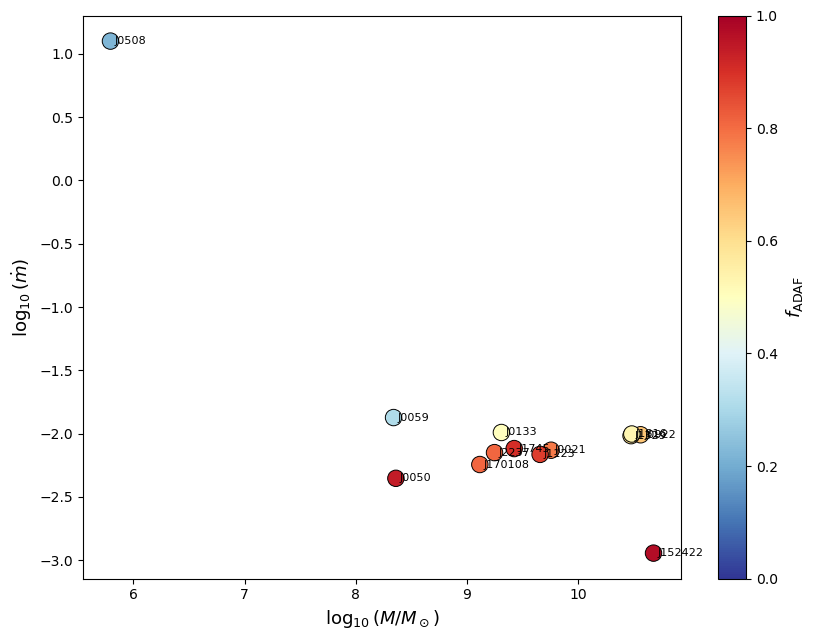

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# DATI LETTI DAL POWERPOINT
# ==========================================================

data = {
    "label": [
        "J0021", "J0050", "J0059", "J0133", "J0508",
        "J0922", "J1123", "J1329", "J1745", "J1816",
        "J2237", "J152422", "J170108"
    ],
    "logM": [
        9.756, 8.360, 8.339, 9.309, 5.793,
        10.561, 9.657, 10.475, 9.424, 10.482,
        9.247, 10.677, 9.115
    ],
    "logmdot": [
        -2.131, -2.353, -1.873, -1.991, 1.101,
        -2.009, -2.164, -2.016, -2.118, -2.003,
        -2.150, -2.944, -2.244
    ],
    "f_ADAF": [
        0.781, 0.938, 0.312, 0.500, 0.219,
        0.656, 0.875, 0.594, 0.906, 0.531,
        0.812, 0.969, 0.812
    ],
    "regime": [
        "ADAF", "ADAF", "SS", "SS", "SS",
        "ADAF", "ADAF", "ADAF", "ADAF", "ADAF",
        "ADAF", "ADAF", "ADAF"
    ]
}

df_plot = pd.DataFrame(data)

# ==========================================================
# GRAFICO
# ==========================================================




fig, ax = plt.subplots(figsize=(8.5, 6.5))

sc = ax.scatter(
    df_plot["logM"],
    df_plot["logmdot"],
    c=df_plot["f_ADAF"],
    cmap="RdYlBu_r",
    s=140,
    edgecolors="black",
    linewidth=0.7,
    vmin=0,
    vmax=1,
    zorder=3
)

# ==========================================================
# ETICHETTE
# ==========================================================

for _, row in df_plot.iterrows():

    ax.text(
        row["logM"] + 0.035,
        row["logmdot"],
        row["label"],
        fontsize=8,
        va="center"
    )

# ==========================================================
# COLORBAR
# ==========================================================

cbar = plt.colorbar(sc, ax=ax)

cbar.set_label(
    r"$f_{\rm ADAF}$",
    fontsize=13
)

# ==========================================================
# ASSI
# ==========================================================

ax.set_xlabel(
    r"$\log_{10}(M/M_\odot)$",
    fontsize=13
)

ax.set_ylabel(
    r"$\log_{10}(\dot m)$",
    fontsize=13
)



plt.tight_layout()
plt.show()

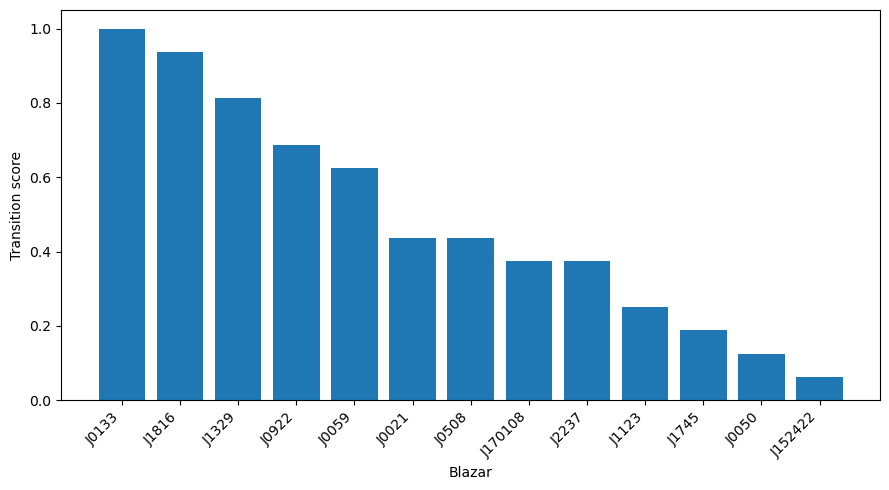

In [3]:
df_score = df_plot.copy()

df_score["transition_score"] = 1 - 2*np.abs(df_score["f_ADAF"] - 0.5)

df_score = df_score.sort_values("transition_score", ascending=False)

plt.figure(figsize=(9,5))

plt.bar(
    df_score["label"],
    df_score["transition_score"]
)

plt.ylabel("Transition score")
plt.xlabel("Blazar")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import spearmanr

rho, p = spearmanr(
    df["m_median_Msun"],
    df["mdot_median"]
)

print(rho, p)

-0.24725274725274726 0.4154051197255382


/tmp/ipykernel_6715/3818609650.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_6715/3818609650.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


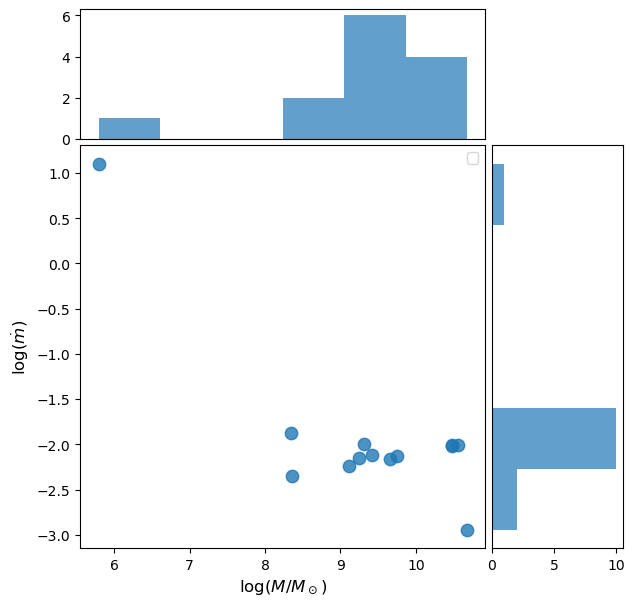

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("risultati_MCMC.csv")

# trasformazione log
logM = np.log10(df["m_median_Msun"])
logmdot = np.log10(df["mdot_median"])

fig = plt.figure(figsize=(7,7))

# griglia
gs = fig.add_gridspec(
    4, 4,
    hspace=0.05,
    wspace=0.05
)

ax = fig.add_subplot(gs[1:, :-1])
ax_top = fig.add_subplot(gs[0, :-1], sharex=ax)
ax_right = fig.add_subplot(gs[1:, -1], sharey=ax)

# scatter centrale
ax.scatter(
    logM,
    logmdot,
    s=80,
    alpha=0.8
)


# istogramma masse
ax_top.hist(
    logM,
    bins=6,
    alpha=0.7
)

# istogramma mdot
ax_right.hist(
    logmdot,
    bins=6,
    orientation='horizontal',
    alpha=0.7
)

# labels
ax.set_xlabel(r'$\log(M/M_\odot)$', fontsize=12)
ax.set_ylabel(r'$\log(\dot m)$', fontsize=12)

# nascondi tick duplicati
plt.setp(ax_top.get_xticklabels(), visible=False)
plt.setp(ax_right.get_yticklabels(), visible=False)

ax_top.tick_params(bottom=False)
ax_right.tick_params(left=False)
ax.legend()

plt.tight_layout()
plt.show()